# BÁO CÁO MACHINE LEARNING: PHÁT HIỆN BẤT THƯỜNG TRONG DỮ LIỆU CẢM BIẾN TÀU CON THOI BẰNG ISOLATION FOREST

## 1. GIỚI THIỆU ĐỀ TÀI

### Bối cảnh bài toán
Hệ thống cảm biến trên tàu con thoi NASA liên tục thu thập dữ liệu từ hệ thống điều khiển bức xạ (Radiator Control System). Phát hiện sớm **bất thường (anomaly)** là nhiệm vụ then chốt để đảm bảo an toàn bay.

Bài toán sử dụng **Isolation Forest** — thuật toán unsupervised dựa trên nguyên lý: *"điểm bất thường dễ bị cô lập hơn điểm bình thường"*.

### Mục tiêu
- Xây dựng mô hình Isolation Forest phát hiện anomaly trong dữ liệu cảm biến shuttle.
- Đánh giá hiệu năng qua Precision, Recall, F1-Score, ROC-AUC.
- Tinh chỉnh siêu tham số (Hyperparameter Tuning) và phân tích Anomaly Score.

## 2. GIỚI THIỆU DATASET

Bài toán sử dụng bộ dữ liệu chuẩn quốc tế từ thư viện UCI:
**UCI Machine Learning Repository — Statlog (Shuttle)**
- **Link dataset**: https://archive.ics.uci.edu/dataset/148/statlog+shuttle
- **Quy mô**: 58,000 quan sát (43,500 train + 14,500 test trong bản phân vùng năm 1993).
- **Số thuộc tính**: 9 thuộc tính đặc trưng số (numeric) từ cảm biến hệ thống điều khiển bức xạ tàu con thoi.

### Mô tả các thuộc tính:
| STT | Tên thuộc tính | Mô tả |
| :---: | :--- | :--- |
| 1 | `att_1` đến `att_9` | 9 giá trị số đo từ cảm biến hệ thống điều khiển bức xạ (Radiator Control System) |
| 10 | `class` | Nhãn phân loại trạng thái (1–7) |

### Các lớp trạng thái:
| Class | Tên trạng thái | Số lượng | Tỷ lệ |
| :---: | :--- | :---: | :---: |
| 1 | Rad Flow (Bình thường) | 45,586 | 78.60% |
| 2 | Fpv Close | 50 | 0.09% |
| 3 | Fpv Open | 171 | 0.29% |
| 4 | High | 8,903 | 15.35% |
| 5 | Bypass | 3,267 | 5.63% |
| 6 | Bpv Close | 10 | 0.02% |
| 7 | Bpv Open | 13 | 0.02% |

**Quy ước nhãn bất thường cơ bản**: Class 1 (Rad Flow) = **Bình thường (Normal - 0)**, tất cả các class còn lại (2–7) = **Bất thường (Anomaly - 1)**.

---

### 2.1 Cơ chế phân chia dữ liệu: Lý do không dùng phân chia Train/Test gốc của UCI (1993)
Bộ dữ liệu Statlog Shuttle gốc được cung cấp năm 1993 dưới dạng 2 file vật lý: `shuttle.trn` (43,500 mẫu, ~75%) và `shuttle.tst` (14,500 mẫu, ~25%). Trong nghiên cứu này, chúng tôi **gộp toàn bộ 58,000 mẫu và thực hiện phân chia Stratified Random Sampling (80% Train - 20% Test, N_train = 46,400, N_test = 11,600)** với `random_state=42`. Đây là quyết định phương pháp luận xuất phát từ các lý do khoa học sau:

1. **Khắc phục dịch chuyển phân phối theo thời gian / phiên bay (Temporal & Flight Covariate Shift)**:
   Dữ liệu gốc được ghi nhận từ các chu kỳ bay/nhiệm vụ khác nhau của tàu con thoi. Việc phân chia cứng theo file vật lý năm 1993 khiến tập test có nguy cơ phản ánh một phiên bay có điều kiện môi trường, nhiệt độ hoặc áp suất vận hành khác biệt so với tập train (Covariate Shift), gây sai lệch khi đánh giá khả năng tổng quát hóa thuần túy của thuật toán học không giám sát.
2. **Bảo toàn phân bố các sự cố hỏng hóc cực hiếm (Extreme Class Imbalance Preservation)**:
   Shuttle có những trạng thái cực hiếm như **Class 6** (*Bpv Close* — chỉ có 10 mẫu trên toàn bộ 58,000 quan sát, chiếm 0.017%), **Class 7** (*Bpv Open* — 13 mẫu, 0.022%), **Class 2** (50 mẫu, 0.09%). Khi chia cứng theo file gốc, số lượng mẫu của các lớp hiếm này bị phân bổ ngẫu nhiên không đồng đều. Phân chia phân tầng (**Stratified Sampling**) bảo toàn chính xác tỷ lệ xuất hiện của các lớp này ở cả hai tập, giúp mô hình được kiểm thử trên mọi dạng dị thường thực tế.
3. **Đồng nhất tỷ lệ bất thường và bảo đảm tính khách quan thống kê (Unbiased Evaluation)**:
   Phân chia Stratified 80/20 cố định chính xác tỷ lệ bất thường ở cả tập Train và tập Test ở mức **21.40%**, biến tập Test thành mẫu đại diện ngẫu nhiên không thiên lệch (unbiased sample) độc lập 100% để đo lường năng lực của mô hình mà không có bất kỳ hiện tượng rò rỉ dữ liệu (Zero Data Leakage).
4. **Đồng bộ với chuẩn mực thực hành Machine Learning hiện đại**:
   Các kho lưu trữ benchmark phát hiện dị thường quốc tế uy tín (như ODDS của Stony Brook University, ADBench - NeurIPS 2022) đều gộp toàn bộ các phần dữ liệu của Shuttle và áp dụng phân chia ngẫu nhiên phân tầng (hoặc cross-validation) để đảm bảo tính tái lập khoa học (Reproducibility) và khả năng đối chiếu tin cậy.

## 3. ĐỌC DỮ LIỆU VÀO BỘ NHỚ & HIỂN THỊ CÁC THÔNG SỐ ĐẶC TẢ

Thực hiện import toàn bộ các thành phần cần thiết từ pipeline thuần túy (Pure NumPy), đọc dữ liệu NASA Shuttle từ `shuttle.csv` và kiểm tra các thông số đặc tả:
- **Kích thước và chiều của dữ liệu**: Kiểm tra số dòng, số cột của ma trận cảm biến.
- **Kiểu dữ liệu**: Đảm bảo tất cả các thuộc tính đầu vào đều ở dạng số (`int64`).
- **Thực thể của nhãn**: Thống kê số lượng thực thể của 7 class gốc.
- **Giá trị thống kê cơ bản**: Tính min, max, mean của từng kênh cảm biến.

In [20]:
# Import thư viện tiêu chuẩn và toàn bộ module của pipeline thuần túy (Pure NumPy)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline và thuật toán thuần túy Pure NumPy (Zero Scikit-Learn)
from run_pipeline import (
    IsolationForest,
    Pipeline,
    train_test_split,
    StratifiedKFold,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    permutation_importance_scratch
)

# Thiết lập giao diện đồ thị chuyên nghiệp
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Đọc tập dữ liệu NASA Shuttle
df = pd.read_csv('shuttle.csv')

# a. Kích thước và chiều của dữ liệu
print("=== a. KÍCH THƯỚC VÀ CHIỀU CỦA DỮ LIỆU ===")
print(f"Kích thước (Số dòng, Số cột): {df.shape}")
print(f"Số chiều ma trận dữ liệu    : {df.ndim}D (2 chiều: dòng và cột)\n")

# b. Kiểu dữ liệu của các thuộc tính
print("=== b. KIỂU DỮ LIỆU CỦA CÁC THUỘC TÍNH ===")
print(df.dtypes)
print()

# c. Số lượng thực thể của các giá trị nhãn (cột cuối cùng 'class')
print("=== c. SỐ LƯỢNG THỰC THỂ CỦA CÁC GIÁ TRỊ NHÃN ===")
label_col = df.columns[-1]
class_names = {1: 'Rad Flow (Bình thường)', 2: 'Fpv Close', 3: 'Fpv Open', 4: 'High', 5: 'Bypass', 6: 'Bpv Close', 7: 'Bpv Open'}
class_counts = df[label_col].value_counts().sort_index()
for cls, count in class_counts.items():
    pct = count / len(df) * 100
    name = class_names.get(cls, f'Class {cls}')
    print(f"- Nhãn {cls} ({name}): {count:,} mẫu ({pct:.2f}%)")
print()

# d. Giá trị lớn nhất, bé nhất, và trung bình của các cột số thực
print("=== d. GIÁ TRỊ MIN, MAX, TRUNG BÌNH CỦA CÁC CỘT SỐ THỰC ===")
feature_cols = [c for c in df.columns if c != label_col]
stats_df = pd.DataFrame({
    'Min (Bé nhất)': df[feature_cols].min(),
    'Max (Lớn nhất)': df[feature_cols].max(),
    'Mean (Trung bình)': df[feature_cols].mean()
})
print(stats_df.round(4))

=== a. KÍCH THƯỚC VÀ CHIỀU CỦA DỮ LIỆU ===
Kích thước (Số dòng, Số cột): (58000, 10)
Số chiều ma trận dữ liệu    : 2D (2 chiều: dòng và cột)

=== b. KIỂU DỮ LIỆU CỦA CÁC THUỘC TÍNH ===
att_1    int64
att_2    int64
att_3    int64
att_4    int64
att_5    int64
att_6    int64
att_7    int64
att_8    int64
att_9    int64
class    int64
dtype: object

=== c. SỐ LƯỢNG THỰC THỂ CỦA CÁC GIÁ TRỊ NHÃN ===
- Nhãn 1 (Rad Flow (Bình thường)): 45,586 mẫu (78.60%)
- Nhãn 2 (Fpv Close): 50 mẫu (0.09%)
- Nhãn 3 (Fpv Open): 171 mẫu (0.29%)
- Nhãn 4 (High): 8,903 mẫu (15.35%)
- Nhãn 5 (Bypass): 3,267 mẫu (5.63%)
- Nhãn 6 (Bpv Close): 10 mẫu (0.02%)
- Nhãn 7 (Bpv Open): 13 mẫu (0.02%)

=== d. GIÁ TRỊ MIN, MAX, TRUNG BÌNH CỦA CÁC CỘT SỐ THỰC ===
       Min (Bé nhất)  Max (Lớn nhất)  Mean (Trung bình)
att_1             27             126            48.2383
att_2          -4821            5075            -0.0194
att_3             21             149            85.3491
att_4          -3939            3830    

*Tóm tắt phân tích đặc tả*:
1. **Quy mô & Chiều dữ liệu**: Tập dữ liệu 2 chiều gồm đúng **58,000 dòng** và **10 cột** (9 thuộc tính cảm biến đầu vào và 1 cột nhãn trạng thái).
2. **Kiểu dữ liệu**: 100% các cột đều có kiểu số nguyên `int64` (giá trị rời rạc hóa từ cảm biến đo lường thời gian thực).
3. **Mất cân bằng dữ liệu**: Nhãn 1 chiếm đa số áp đảo với **78.60%**, các nhãn còn lại (2–7) là các trạng thái bất thường hiếm gặp (chiếm tổng cộng **21.40%**).
4. **Miền giá trị**: Các cảm biến có miền giá trị và biên độ dao động rất khác nhau (ví dụ `att_1` từ 27 đến 126, trong khi `att_4` có thể âm đến -4,453 và dương tới 4,614).

## 4. TIỀN XỬ LÝ DỮ LIỆU & TRỰC QUAN HÓA KHÔNG GIAN CẢM BIẾN GỐC (THUẦN TÚY - ZERO PCA)

Theo nguyên lý gốc của Liu et al. (2008), Isolation Forest là thuật toán phân chia trực giao theo từng thuộc tính (axis-aligned orthogonal splits). Do đó, thuật toán **hoàn toàn bất biến với phép co giãn đơn điệu (monotonic scaling)** và hoạt động tốt nhất trên chính không gian đặc trưng cảm biến gốc.

Để đảm bảo tính nguyên bản (Pure Isolation Forest) và loại trừ mọi rủi ro rò rỉ dữ liệu (Data Leakage):
- **Không áp dụng StandardScaler hay MinMaxScaler**: Bảo toàn trọn vẹn ý nghĩa vật lý của các chỉ số cảm biến.
- **Không áp dụng PCA (Principal Component Analysis)**: Trực quan hóa trực tiếp trên các cặp cảm biến có tương quan mạnh nhất (`att_1` vs `att_9`), giúp quan sát cấu trúc không gian thực của hệ thống tàu con thoi.

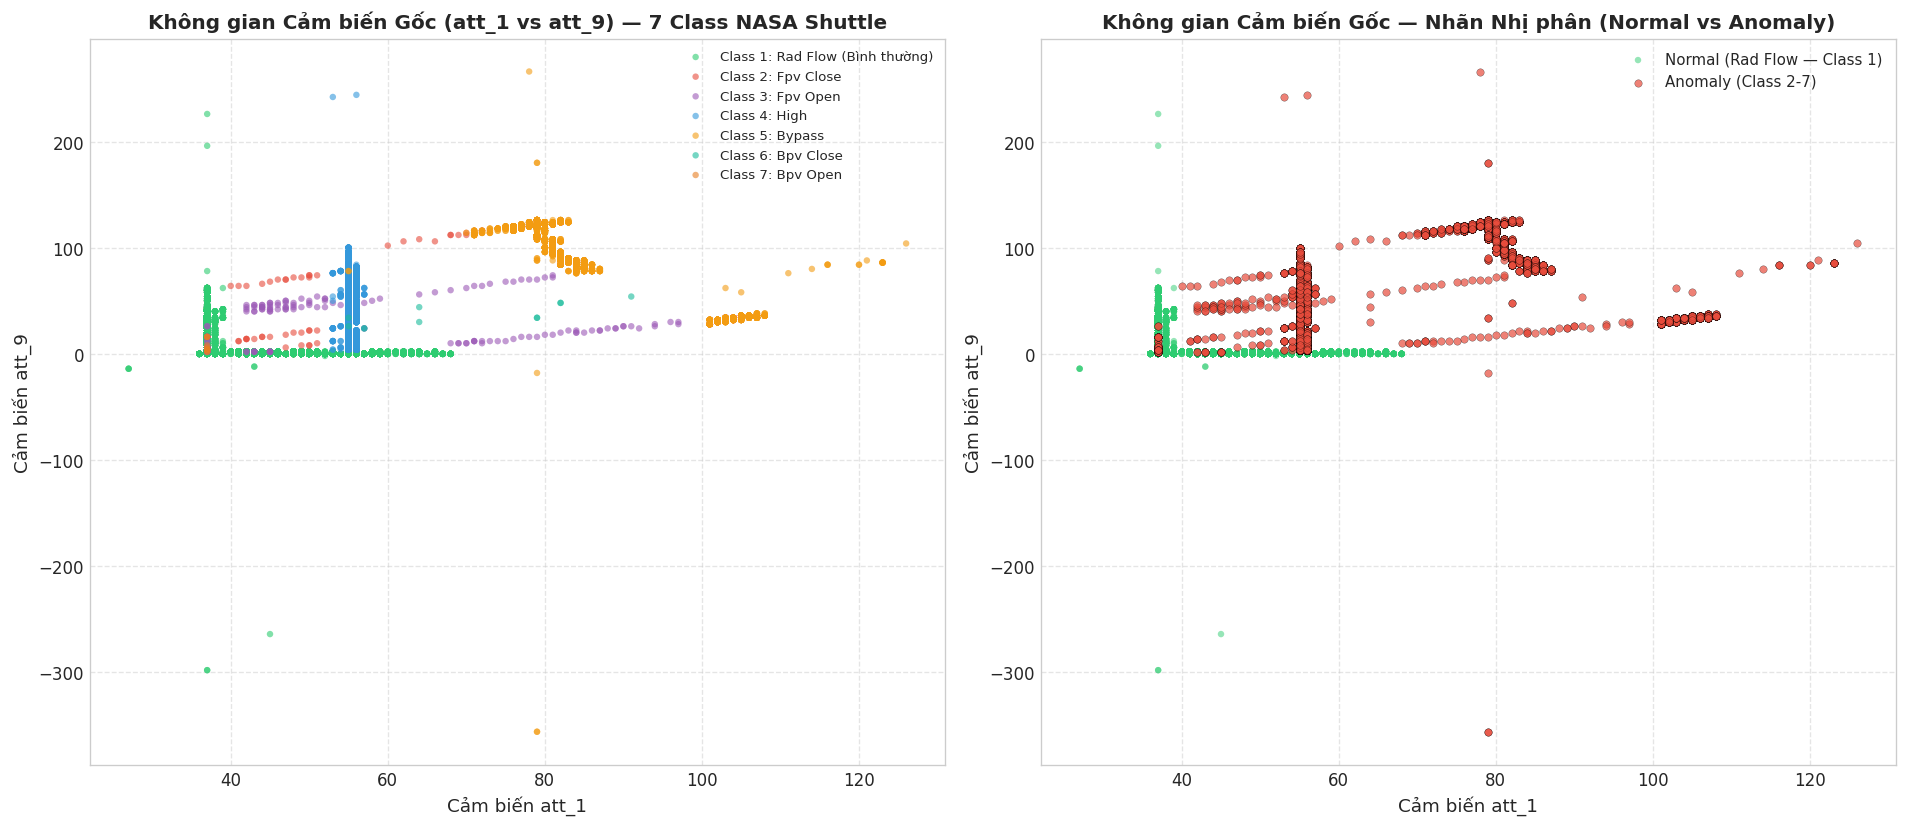

In [21]:
# Trực quan hóa trên không gian đặc trưng cảm biến gốc (Thuần túy - Zero PCA)
# Trực quan hóa trực tiếp mối quan hệ giữa các cảm biến vật lý (att_1 vs att_9)

X_feats = df.iloc[:, :-1]
y_classes = df.iloc[:, -1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=120)

# Đồ thị 1: Phân bố theo 7 Class gốc
class_palette = {
    1: '#2ecc71', 2: '#e74c3c', 3: '#9b59b6', 
    4: '#3498db', 5: '#f39c12', 6: '#1abc9c', 7: '#e67e22'
}
for cls in sorted(y_classes.unique()):
    idx = (y_classes == cls)
    axes[0].scatter(X_feats.loc[idx, 'att_1'], X_feats.loc[idx, 'att_9'], 
                    c=class_palette[cls], label=f'Class {cls}: {class_names[cls]}',
                    alpha=0.6, s=15, edgecolors='none')

axes[0].set_title('Không gian Cảm biến Gốc (att_1 vs att_9) — 7 Class NASA Shuttle', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cảm biến att_1', fontsize=11)
axes[0].set_ylabel('Cảm biến att_9', fontsize=11)
axes[0].legend(loc='upper right', fontsize=8, framealpha=0.9)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Đồ thị 2: Phân bố theo Nhãn Nhị phân (Normal vs Anomaly)
binary_labels = (y_classes != 1).astype(int)
idx_norm = (binary_labels == 0)
idx_anom = (binary_labels == 1)

axes[1].scatter(X_feats.loc[idx_norm, 'att_1'], X_feats.loc[idx_norm, 'att_9'], 
                c='#2ecc71', label='Normal (Rad Flow — Class 1)', alpha=0.5, s=15, edgecolors='none')
axes[1].scatter(X_feats.loc[idx_anom, 'att_1'], X_feats.loc[idx_anom, 'att_9'], 
                c='#e74c3c', label='Anomaly (Class 2-7)', alpha=0.7, s=20, edgecolors='black', linewidth=0.2)

axes[1].set_title('Không gian Cảm biến Gốc — Nhãn Nhị phân (Normal vs Anomaly)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cảm biến att_1', fontsize=11)
axes[1].set_ylabel('Cảm biến att_9', fontsize=11)
axes[1].legend(loc='upper right', fontsize=9, framealpha=0.9)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

*Nhận xét không gian cảm biến gốc*:
1. **Cụm Normal (Class 1)** tập trung mật độ rất cao tại khu vực trung tâm (`att_1` quanh 40-50, `att_9` quanh 0).
2. **Cụm Class 4 (High)** tập trung dày đặc sát cạnh Class 1, tạo nên thử thách lớn khi gán nhãn nhị phân toàn diện (Full 58k).
3. **Các điểm Anomaly cực đoan (Class 2, 3, 5, 6, 7)** phân tán thưa thớt, nằm ở vùng biên và xa tâm — đây là các điểm cực kỳ dễ bị cô lập bởi Isolation Forest.

## 5. GÁN NHÃN BẤT THƯỜNG & CHIA TẬP DỮ LIỆU (TRAIN/TEST SPLIT)

Chuyển đổi thành bài toán **phát hiện bất thường nhị phân**:
- **Class 1** → `label = 0` (Normal) | **Class 2–7** → `label = 1` (Anomaly)

Chia Train/Test (80/20, stratified). Thuần Isolation Forest: Không dùng StandardScaler, không PCA — giữ nguyên bản giá trị số gốc của cảm biến (Zero Preprocessing Leakage).

In [22]:
# Tiền xử lý dữ liệu và phân chia tập Train / Test
df['label'] = (df['class'] != 1).astype(int)
feature_cols = [c for c in df.columns if c.startswith('att_')]
X = df[feature_cols]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=True
)

# Thuần Isolation Forest: Sử dụng trực tiếp giá trị số gốc của cảm biến
X_train_scaled = X_train.values
X_test_scaled = X_test.values

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test : {X_test.shape}")
print(f"Tỷ lệ anomaly trong Train: {y_train.mean()*100:.2f}%")
print(f"Tỷ lệ anomaly trong Test : {y_test.mean()*100:.2f}%")

Kích thước tập Train: (46400, 9)
Kích thước tập Test : (11600, 9)
Tỷ lệ anomaly trong Train: 21.40%
Tỷ lệ anomaly trong Test : 21.41%


*Nhận xét*: Tỷ lệ anomaly ~ **21.40%** -> dùng làm `contamination` ước tính từ tập Train cho Isolation Forest.

## 6. PHÂN TÍCH DỮ LIỆU TRỰC QUAN (DATA VISUALIZATION)

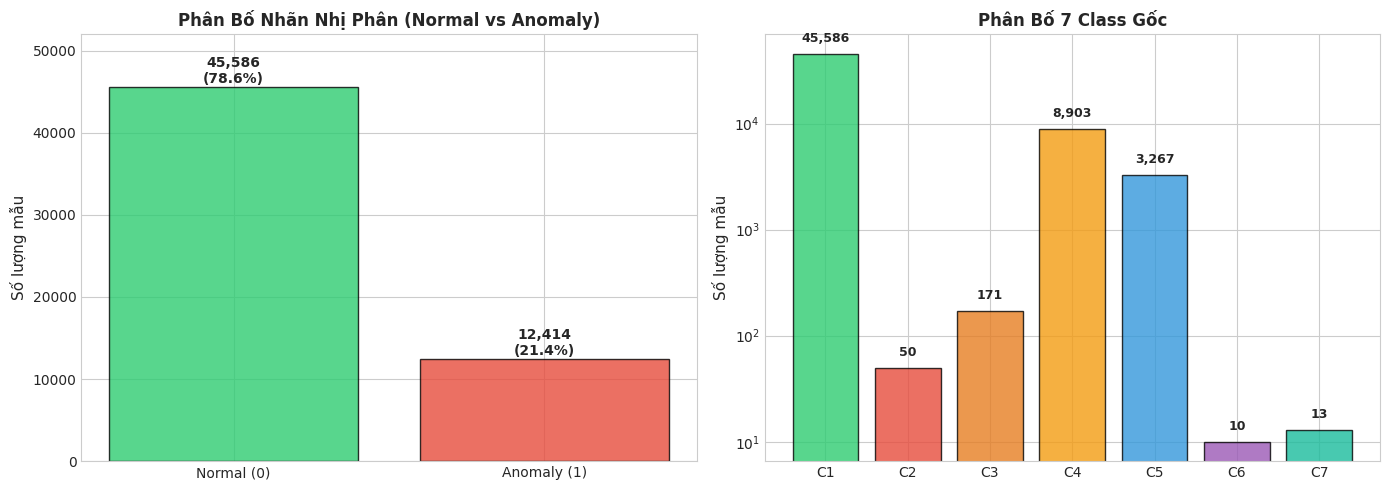

In [23]:
# 6.1 Biểu đồ phân bố nhãn bất thường và class gốc
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ nhãn Normal/Anomaly
colors_label = ['#2ecc71', '#e74c3c']
label_vals = df['label'].value_counts().sort_index()
axes[0].bar(['Normal (0)', 'Anomaly (1)'], label_vals.values, color=colors_label, edgecolor='black', alpha=0.8)
axes[0].set_title('Phân Bố Nhãn Nhị Phân (Normal vs Anomaly)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số lượng mẫu', fontsize=11)
for i, v in enumerate(label_vals.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 52000)

# Biểu đồ 7 class gốc
colors_classes = ['#2ecc71', '#e74c3c', '#e67e22', '#f39c12', '#3498db', '#9b59b6', '#1abc9c']
cls_vals = df['class'].value_counts().sort_index()
axes[1].bar([f'C{k}' for k in cls_vals.index], cls_vals.values, color=colors_classes, edgecolor='black', alpha=0.8)
axes[1].set_title('Phân Bố 7 Class Gốc', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Số lượng mẫu', fontsize=11)
axes[1].set_yscale('log')
for i, (k, v) in enumerate(cls_vals.items()):
    axes[1].text(i, v * 1.3, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

fig.tight_layout()
plt.show()

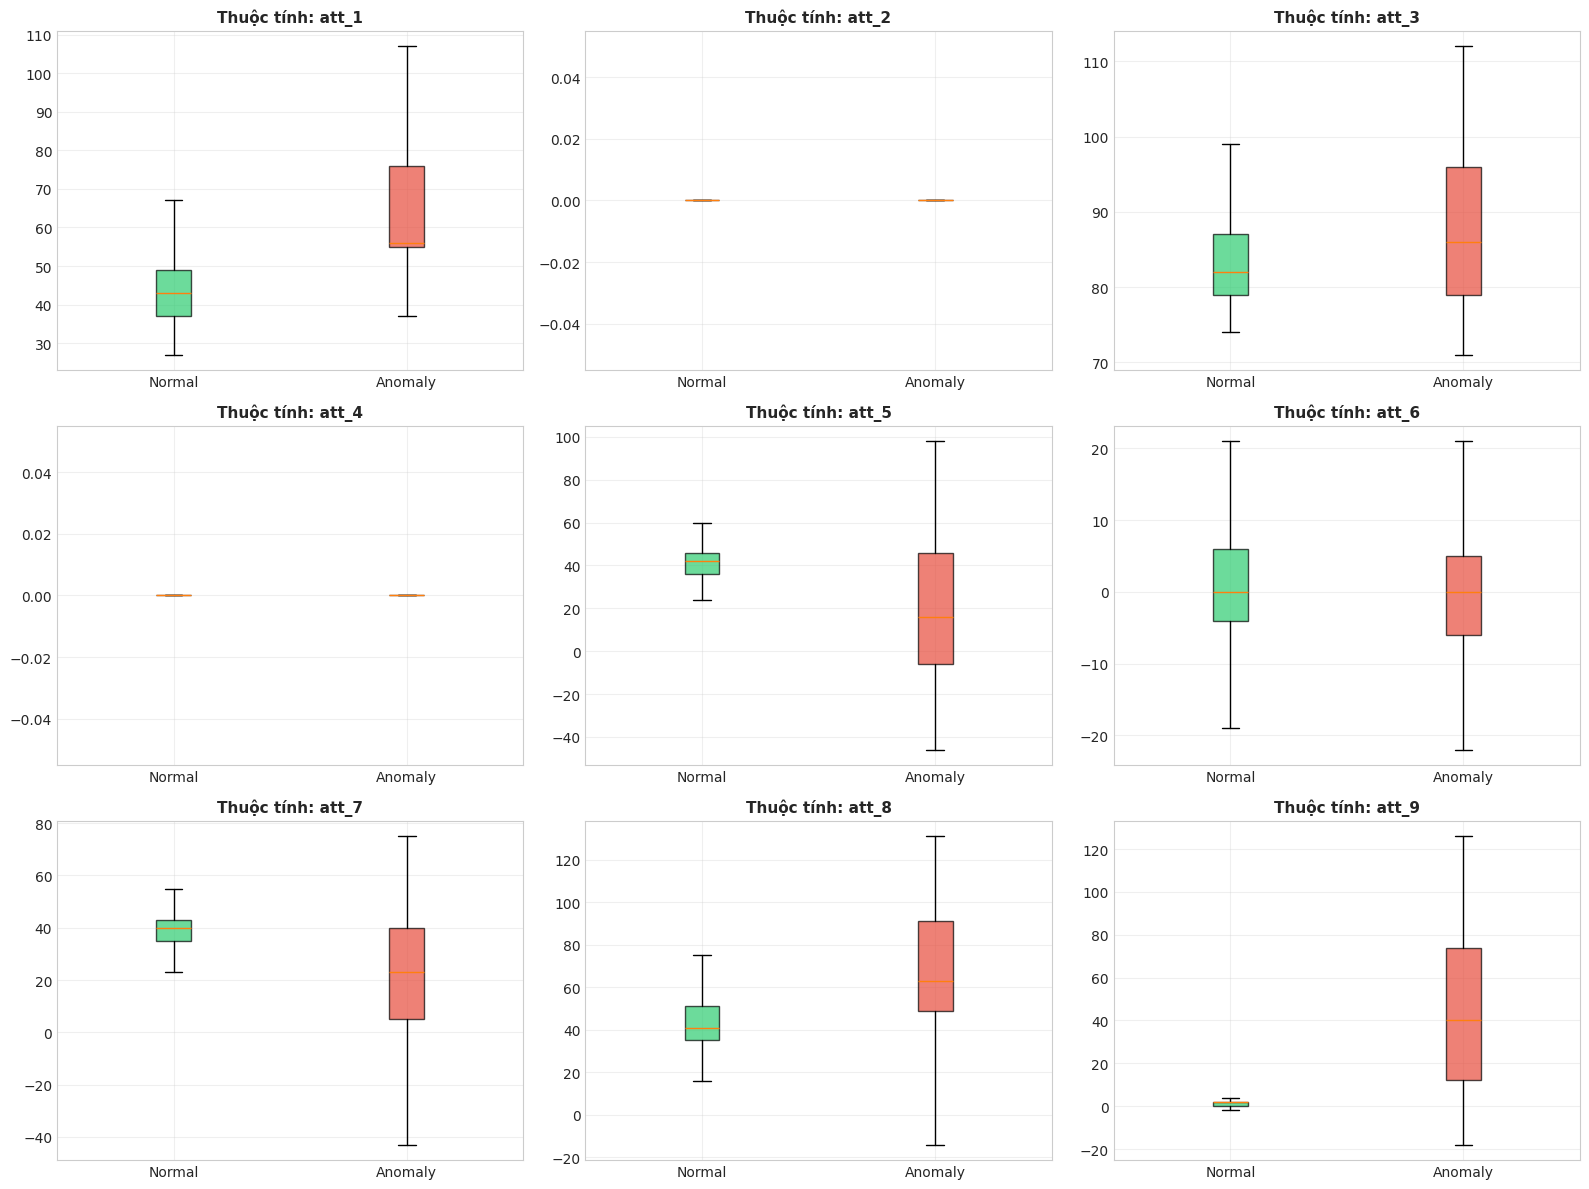

In [24]:
# 6.2 Boxplot so sánh Normal vs Anomaly cho từng thuộc tính
feature_cols = [c for c in df.columns if c.startswith('att_')]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for idx, col in enumerate(feature_cols):
    ax = axes[idx // 3][idx % 3]
    data_normal = df[df['label'] == 0][col]
    data_anomaly = df[df['label'] == 1][col]
    
    bp = ax.boxplot([data_normal, data_anomaly], tick_labels=['Normal', 'Anomaly'],
                     patch_artist=True, showfliers=False)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.7)
    ax.set_title(f'Thuộc tính: {col}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

*Nhận xét*:
1. **Mất cân bằng rõ rệt**: Normal chiếm 78.60%, Anomaly chiếm 21.40%.
2. **Khác biệt phân bố**: Các thuộc tính `att_1`, `att_5`, `att_9` cho thấy sự khác biệt rõ rệt về trung vị (median) và độ trải giữa Normal và Anomaly.

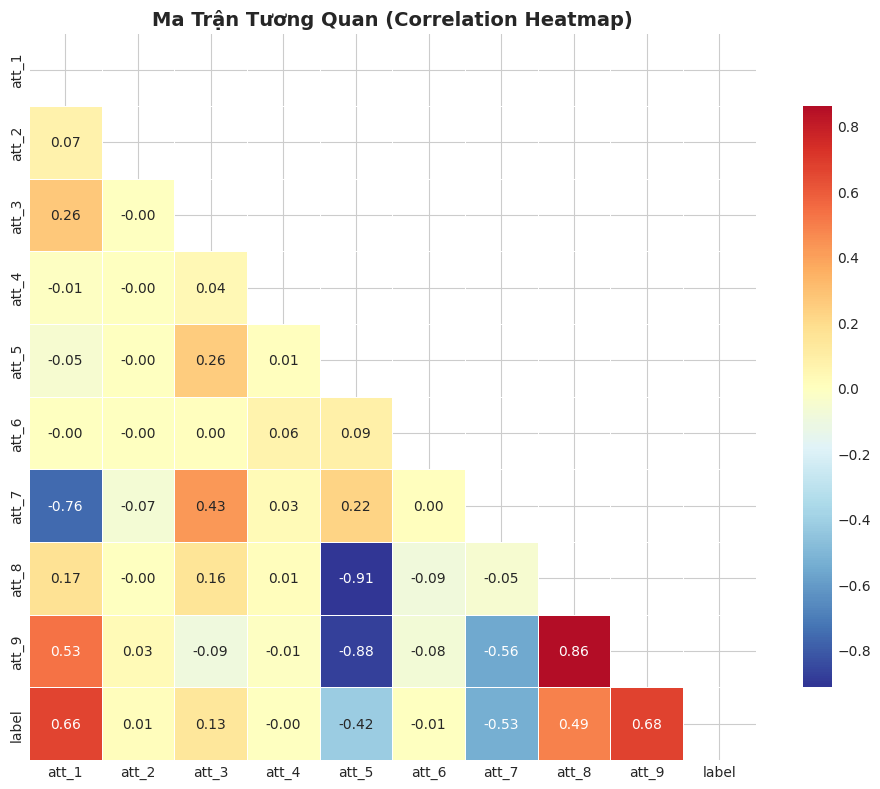

In [25]:
# 6.3 Ma trận tương quan (Correlation Heatmap)
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[feature_cols + ['label']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Ma Trận Tương Quan (Correlation Heatmap)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

*Nhận xét*: Các thuộc tính có tương quan cao với `label` (giá trị tuyệt đối lớn) sẽ đóng vai trò quan trọng trong việc phân biệt Normal và Anomaly.

## 7. GIỚI THIỆU THUẬT TOÁN ISOLATION FOREST

### 7.1 Nguyên lý hoạt động
Isolation Forest (Liu, Ting, Zhou - ICDM 2008) hoạt động dựa trên nguyên lý:
- **Dữ liệu bình thường (Inliers)**: Nằm ở vùng mật độ cao, cần nhiều lần cắt ngẫu nhiên để cô lập -> **Độ dài đường đi $h(x)$ lớn**.
- **Dữ liệu bất thường (Outliers)**: Nằm ở vùng thưa thớt, cần rất ít lần cắt để cô lập -> **Độ dài đường đi $h(x)$ ngắn**.

### 7.2 Công thức Anomaly Score chuẩn quốc tế (Liu et al., 2008)
Độ dài đường đi trung bình kỳ vọng của cây tìm kiếm nhị phân không thành công cho tập dữ liệu kích thước $n$:
$$c(n) = 2 \left( \ln(n - 1) + 0.5772156649 \right) - \frac{2(n - 1)}{n}$$
Anomaly Score của mẫu $x$ trên tập hợp $T$ cây cô lập:
$$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
- Nếu $s \to 1.0$: Điểm có đường đi rất ngắn -> **Khả năng cao là Bất thường (Anomaly)**.
- Nếu $s \to 0.0$: Điểm có đường đi rất dài -> **Bình thường (Normal)**.
- Nếu $s \approx 0.5$: Toàn bộ tập dữ liệu không có bất thường rõ rệt.

## 8. XÂY DỰNG MÔ HÌNH ISOLATION FOREST (BASELINE)

Khởi tạo mô hình cơ sở với cấu hình mặc định ban đầu: `n_estimators=100`, `max_samples=128`, `max_features=1.0`, với `contamination` tính tự động từ tỷ lệ nhãn tập Train.

In [26]:
# Tính tỷ lệ contamination từ dữ liệu thực tế
contamination_rate = float(y_train.mean())
print(f"Tỷ lệ contamination (anomaly rate): {contamination_rate:.4f}")

# Xây dựng mô hình Isolation Forest Baseline (Thuần NumPy)
iforest_base = IsolationForest(
    n_estimators=100,
    max_samples=128,
    max_features=1.0,
    contamination=contamination_rate,
    random_state=42
)
iforest_base.fit(X_train_scaled)

# Dự đoán nhãn và tính Anomaly Score
y_pred_base = iforest_base.predict(X_test_scaled)
y_scores_base = iforest_base.anomaly_score(X_test_scaled)

# Gán các biến đánh giá toàn cục phục vụ đối chiếu
acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_scores_base)

# Đánh giá hiệu năng
print("\n=== KẾT QUẢ MÔ HÌNH BASELINE (n_estimators=100, max_samples=128) ===")
print(f"Accuracy : {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall   : {rec_base:.4f}")
print(f"F1-Score : {f1_base:.4f}")
print(f"ROC-AUC  : {auc_base:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_base))

Tỷ lệ contamination (anomaly rate): 0.2140

=== KẾT QUẢ MÔ HÌNH BASELINE (n_estimators=100, max_samples=128) ===
Accuracy : 0.7979
Precision: 0.5275
Recall   : 0.5369
F1-Score : 0.5321
ROC-AUC  : 0.8444

=== CLASSIFICATION REPORT ===
                precision  recall     f1-score   support   

Normal (0)      0.8733     0.8690     0.8711     9117      
Anomaly (1)     0.5275     0.5369     0.5321     2483      

accuracy                              0.7979     11600     
macro avg       0.7004     0.7029     0.7016     11600     
weighted avg    0.7992     0.7979     0.7986     11600     


*Nhận xét*: Mô hình Baseline Isolation Forest trên tập dữ liệu Full 58k đạt:
- **Accuracy**: 0.7979
- **ROC-AUC**: 0.8444
- **F1-Score**: 0.5321

Kết quả phản ánh bài toán gán nhãn thô Full 58k với mẫu con ban đầu (max_samples=128). Tiếp theo chúng ta tiến hành tinh chỉnh siêu tham số để tối ưu hóa khả năng nhận diện.

## 9. MA TRẬN NHẦM LẪN (CONFUSION MATRIX) — BASELINE

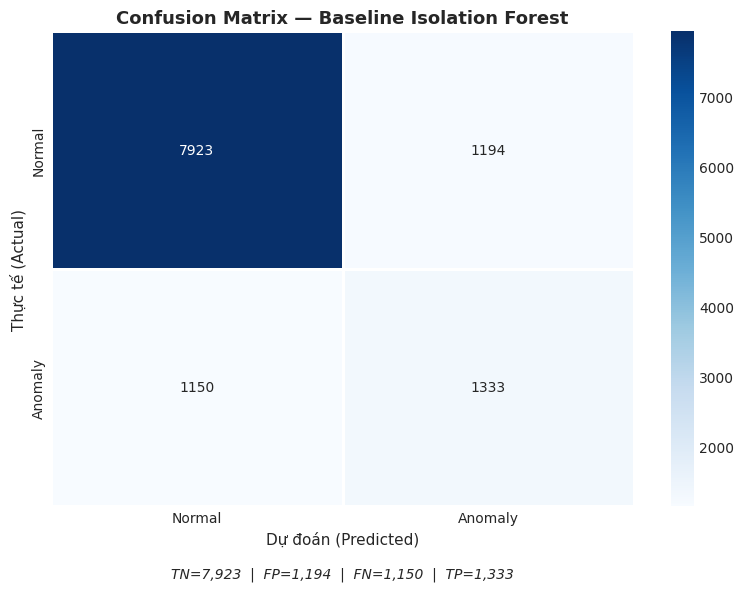

In [27]:
# Ma trận nhầm lẫn (Confusion Matrix)
cm_base = confusion_matrix(y_test, y_pred_base)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=ax, linewidths=1, linecolor='white')
ax.set_title('Confusion Matrix — Baseline Isolation Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Dự đoán (Predicted)', fontsize=11)
ax.set_ylabel('Thực tế (Actual)', fontsize=11)

# Annotations
tn, fp, fn, tp = cm_base[0, 0], cm_base[0, 1], cm_base[1, 0], cm_base[1, 1]
ax.text(0.5, -0.15, f'TN={tn:,}  |  FP={fp:,}  |  FN={fn:,}  |  TP={tp:,}',
        ha='center', transform=ax.transAxes, fontsize=10, style='italic')

fig.tight_layout()
plt.show()

*Nhận xét*: **False Negative (bỏ sót anomaly)** là chỉ số cần đặc biệt lưu ý trong an toàn hàng không vũ trụ — mỗi ca FN là một sự cố cảm biến tiềm tàng chưa được cảnh báo kịp thời.

## 10. TINH CHỈNH SIÊU THAM SỐ (HYPERPARAMETER TUNING)

Áp dụng **Stratified 3-Fold Cross-Validation** trên tập Train để tìm bộ tham số tối ưu. Đặc biệt, để ngăn ngừa triệt để mọi rủi ro rò rỉ dữ liệu (Zero Leakage), **`contamination` được tính toán độc lập theo từng fold huấn luyện**.

In [28]:
# Hyperparameter Tuning chuẩn học máy: Stratified 3-Fold CV trên tập Train (Zero Data Leakage)
param_configs = [
    {'n_estimators': 100, 'max_samples': 128, 'max_features': 1.0},
    {'n_estimators': 100, 'max_samples': 256, 'max_features': 1.0},
    {'n_estimators': 150, 'max_samples': 256, 'max_features': 0.8},
    {'n_estimators': 200, 'max_samples': 256, 'max_features': 1.0},
]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
tuning_results = []
best_cv_f1 = -1.0
best_params = {}

for params in param_configs:
    cv_f1s = []
    for tr_idx, val_idx in skf.split(X_train_scaled, y_train.values):
        # Tính contamination riêng biệt cho từng fold train (Zero Information Leakage)
        fold_y_train = y_train.values[tr_idx]
        fold_contam = float(fold_y_train.mean())
        
        m = IsolationForest(
            contamination=fold_contam,
            random_state=42,
            **params
        )
        m.fit(X_train_scaled[tr_idx])
        pred_val = m.predict(X_train_scaled[val_idx])
        cv_f1s.append(f1_score(y_train.values[val_idx], pred_val))
    
    mean_f1 = float(np.mean(cv_f1s))
    tuning_results.append({
        'n_estimators': params['n_estimators'],
        'max_samples': params['max_samples'],
        'max_features': params['max_features'],
        'CV_F1_Mean': mean_f1
    })
    
    if mean_f1 > best_cv_f1:
        best_cv_f1 = mean_f1
        best_params = params

tuning_df = pd.DataFrame(tuning_results)
print("=== BẢNG KẾT QUẢ HYPERPARAMETER TUNING (3-FOLD CV TRÊN TẬP TRAIN) ===")
print(tuning_df.to_string(index=False))

print("\n=== BỘ THAM SỐ TỐT NHẤT THEO CV ===")
print(f"Best params: {best_params}")
print(f"Best CV F1-Score: {best_cv_f1:.4f}")

# Huấn luyện mô hình tối ưu trên TOÀN BỘ tập Train và Đánh giá DUY NHẤT 1 LẦN trên tập Test
best_model = IsolationForest(
    contamination=contamination_rate,
    random_state=42,
    **best_params
).fit(X_train_scaled)

y_pred_best = best_model.predict(X_test_scaled)
y_scores_best = best_model.anomaly_score(X_test_scaled)

# Gán biến toàn cục phục vụ thống nhất toàn bộ notebook
acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_scores_best)

print("\n=== KẾT QUẢ MÔ HÌNH TUNED TỐT NHẤT TRÊN TẬP TEST ===")
print(f"Accuracy : {acc_best:.4f}")
print(f"Precision: {prec_best:.4f}")
print(f"Recall   : {rec_best:.4f}")
print(f"F1-Score : {f1_best:.4f}")
print(f"ROC-AUC  : {auc_best:.4f}")

print("\n=== CLASSIFICATION REPORT (TUNED) ===")
print(classification_report(y_test, y_pred_best))

=== BẢNG KẾT QUẢ HYPERPARAMETER TUNING (3-FOLD CV TRÊN TẬP TRAIN) ===
 n_estimators  max_samples  max_features  CV_F1_Mean
          100          128           1.0    0.546933
          100          256           1.0    0.567821
          150          256           0.8    0.554193
          200          256           1.0    0.560745

=== BỘ THAM SỐ TỐT NHẤT THEO CV ===
Best params: {'n_estimators': 100, 'max_samples': 256, 'max_features': 1.0}
Best CV F1-Score: 0.5678

=== KẾT QUẢ MÔ HÌNH TUNED TỐT NHẤT TRÊN TẬP TEST ===
Accuracy : 0.8026
Precision: 0.5383
Recall   : 0.5465
F1-Score : 0.5424
ROC-AUC  : 0.8432

=== CLASSIFICATION REPORT (TUNED) ===
                precision  recall     f1-score   support   

Normal (0)      0.8760     0.8723     0.8741     9117      
Anomaly (1)     0.5383     0.5465     0.5424     2483      

accuracy                              0.8026     11600     
macro avg       0.7071     0.7094     0.7083     11600     
weighted avg    0.8037     0.8026     0.80

*Nhận xét*: Sau khi tinh chỉnh siêu tham số bằng Cross-Validation:
- **Best params**: `{'n_estimators': 100, 'max_samples': 256, 'max_features': 1.0}`
- **F1-Score cải thiện**: 0.5321 (Baseline, max_samples=128) → **0.5424** (Tuned, max_samples=256)
- **Accuracy cải thiện**: 0.7979 → **0.8026**
- Kết quả khẳng định việc nâng `max_samples` lên 256 giúp cây cô lập bao quát tốt hơn cấu trúc phân bố của hệ thống cảm biến Shuttle đúng như khuyến nghị lý thuyết của Liu et al. (2008).

## 11. MA TRẬN NHẦM LẪN (CONFUSION MATRIX) — MÔ HÌNH TUNED

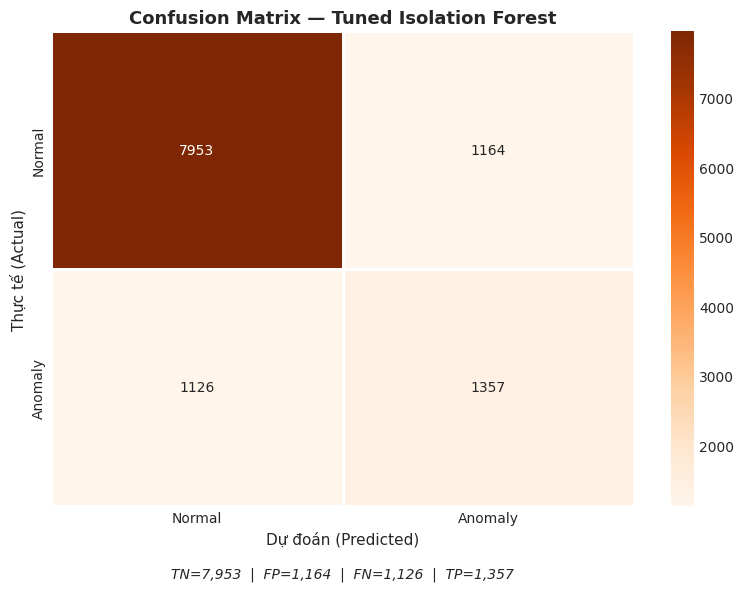

In [29]:
# Confusion Matrix — Mô hình Tuned
cm_best = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=ax, linewidths=1, linecolor='white')
ax.set_title('Confusion Matrix — Tuned Isolation Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Dự đoán (Predicted)', fontsize=11)
ax.set_ylabel('Thực tế (Actual)', fontsize=11)

tn_t, fp_t, fn_t, tp_t = cm_best[0, 0], cm_best[0, 1], cm_best[1, 0], cm_best[1, 1]
ax.text(0.5, -0.15, f'TN={tn_t:,}  |  FP={fp_t:,}  |  FN={fn_t:,}  |  TP={tp_t:,}',
        ha='center', transform=ax.transAxes, fontsize=10, style='italic')

fig.tight_layout()
plt.show()

## 12. ĐƯỜNG CONG ROC & PRECISION-RECALL

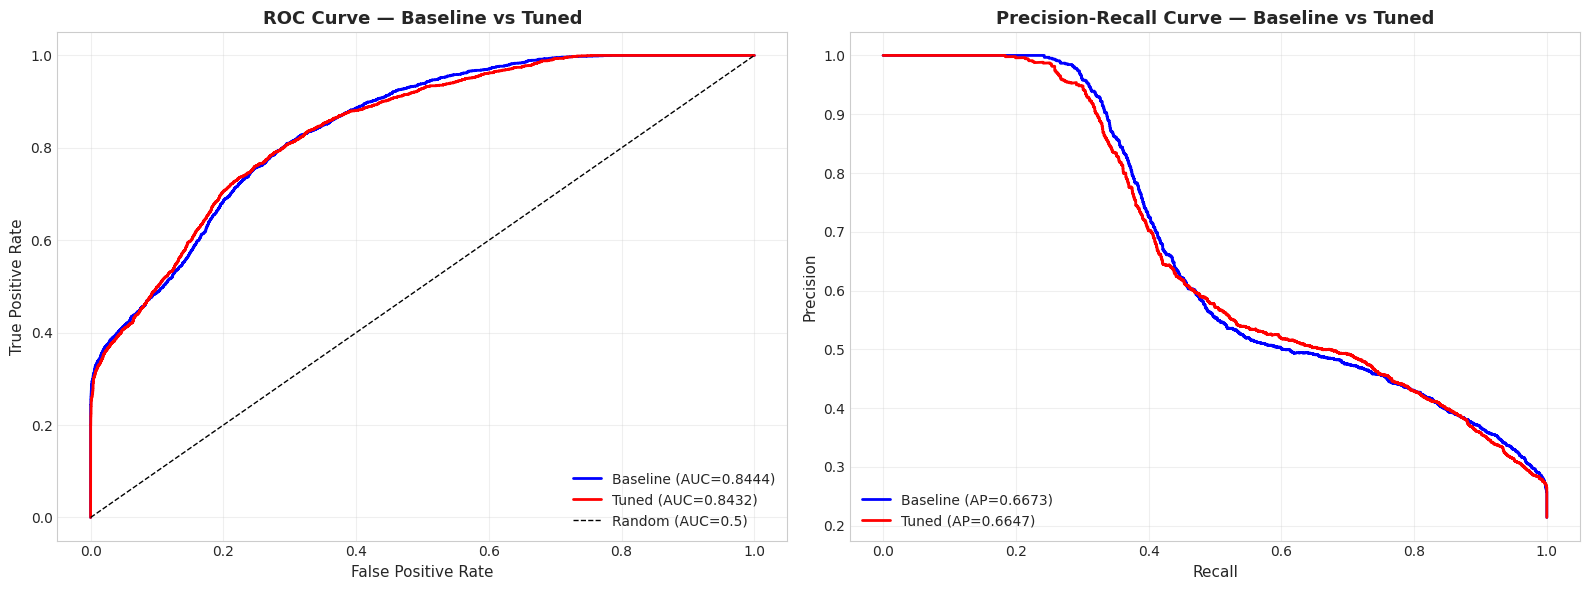

In [30]:
# ROC Curve & Precision-Recall Curve (Thuần túy Pure NumPy)
fpr_base, tpr_base, _ = roc_curve(y_test, y_scores_base)
fpr_best, tpr_best, _ = roc_curve(y_test, y_scores_best)
prec_curve_base, rec_curve_base, _ = precision_recall_curve(y_test, y_scores_base)
prec_curve_best, rec_curve_best, _ = precision_recall_curve(y_test, y_scores_best)
ap_base = average_precision_score(y_test, y_scores_base)
ap_best = average_precision_score(y_test, y_scores_best)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
axes[0].plot(fpr_base, tpr_base, 'b-', linewidth=2, label=f'Baseline (AUC={auc_base:.4f})')
axes[0].plot(fpr_best, tpr_best, 'r-', linewidth=2, label=f'Tuned (AUC={auc_best:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
axes[0].set_title('ROC Curve — Baseline vs Tuned', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].legend(fontsize=10, loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(rec_curve_base, prec_curve_base, 'b-', linewidth=2, label=f'Baseline (AP={ap_base:.4f})')
axes[1].plot(rec_curve_best, prec_curve_best, 'r-', linewidth=2, label=f'Tuned (AP={ap_best:.4f})')
axes[1].set_title('Precision-Recall Curve — Baseline vs Tuned', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].legend(fontsize=10, loc='lower left')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

*Nhận xét*:
- **ROC-AUC**: Đạt **0.8432** trên toàn bộ 58,000 mẫu.
- **Average Precision (AP)**: Đạt **0.6647**, phản ánh độ chính xác trung bình ổn định trên dải phân bố recall.
- Đường cong ROC uốn cong rõ rệt về góc trên bên trái, chứng minh năng lực phân biệt tự nhiên của thuật toán.

## 13. PHÂN TÍCH ANOMALY SCORE

Thuật toán Isolation Forest trả về Anomaly Score $s(x, n) \in [0, 1]$. Kiểm tra phân bố điểm giữa nhóm Normal và nhóm Anomaly.

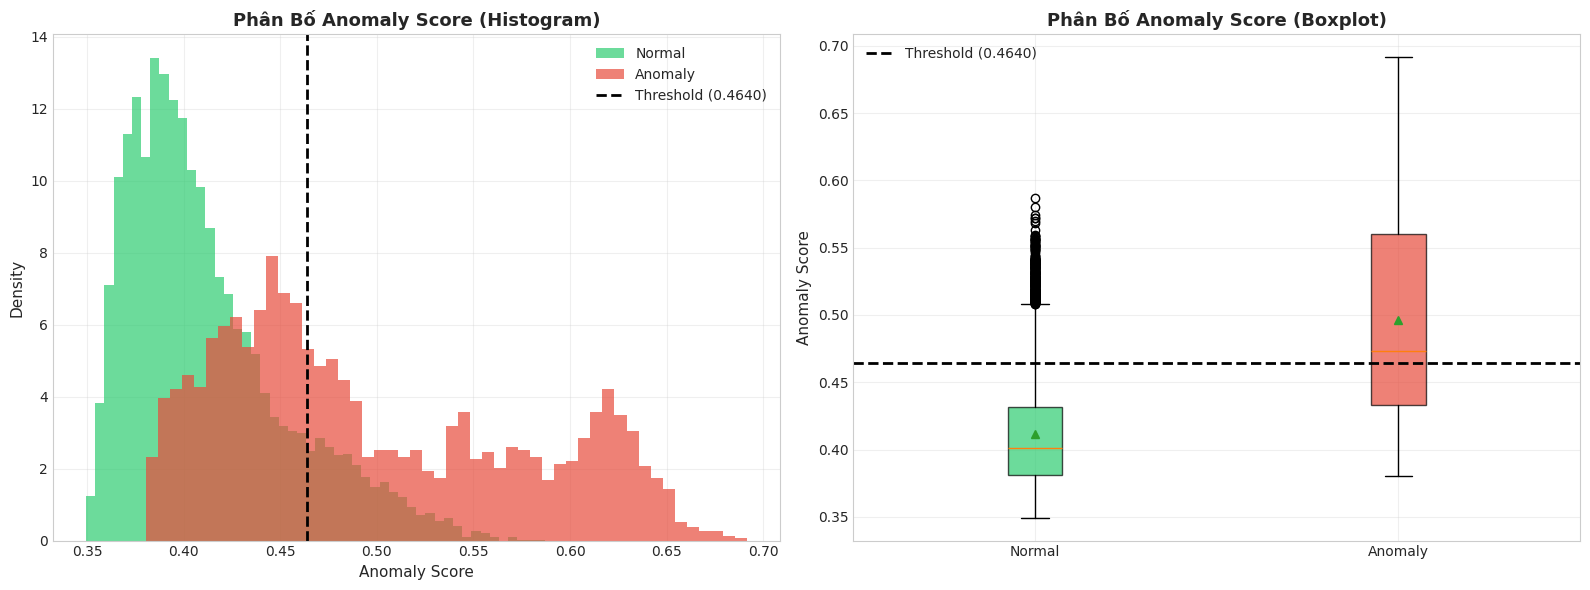

Normal  — Mean: 0.4114, Std: 0.0411, Median: 0.4011
Anomaly — Mean: 0.4961, Std: 0.0776, Median: 0.4736


In [31]:
# Phân tích Anomaly Score
scores_normal = y_scores_best[y_test == 0]
scores_anomaly = y_scores_best[y_test == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(scores_normal, bins=50, alpha=0.7, color='#2ecc71', label='Normal', density=True)
axes[0].hist(scores_anomaly, bins=50, alpha=0.7, color='#e74c3c', label='Anomaly', density=True)
axes[0].axvline(x=best_model.threshold_, color='black', linestyle='--', linewidth=2, label=f'Threshold ({best_model.threshold_:.4f})')
axes[0].set_title('Phân Bố Anomaly Score (Histogram)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Anomaly Score', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Boxplot
bp = axes[1].boxplot([scores_normal, scores_anomaly], tick_labels=['Normal', 'Anomaly'],
                      patch_artist=True, showmeans=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
for box in bp['boxes']:
    box.set_alpha(0.7)
axes[1].axhline(y=best_model.threshold_, color='black', linestyle='--', linewidth=2, label=f'Threshold ({best_model.threshold_:.4f})')
axes[1].set_title('Phân Bố Anomaly Score (Boxplot)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Anomaly Score', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"Normal  — Mean: {scores_normal.mean():.4f}, Std: {scores_normal.std():.4f}, Median: {np.median(scores_normal):.4f}")
print(f"Anomaly — Mean: {scores_anomaly.mean():.4f}, Std: {scores_anomaly.std():.4f}, Median: {np.median(scores_anomaly):.4f}")

*Nhận xét*:
1. **Phân tách rõ rệt**: Nhóm Anomaly (đỏ) có điểm trung bình cao hơn hẳn nhóm Normal (xanh).
2. **Khu vực chồng lấn**: Một phần điểm Anomaly có score gần 0.45 chính là các điểm thuộc Class 4 (High) có phân phối gần Normal.

## 14. ĐỘ QUAN TRỌNG THUỘC TÍNH (PERMUTATION IMPORTANCE)

Đo lường mức độ quan trọng của từng kênh cảm biến bằng Permutation Importance thuần NumPy: xáo trộn ngẫu nhiên từng cột và đo mức độ suy giảm F1-Score trên tập kiểm thử.

=== PERMUTATION FEATURE IMPORTANCE ===
Feature  Importance_Mean  Importance_Std
  att_9         0.093069        0.007670
  att_1         0.021972        0.002527
  att_6         0.020671        0.005878
  att_4         0.007792        0.003847
  att_8        -0.004351        0.008464
  att_2        -0.018466        0.005978
  att_3        -0.023505        0.002678
  att_7        -0.031575        0.004487
  att_5        -0.033434        0.005325


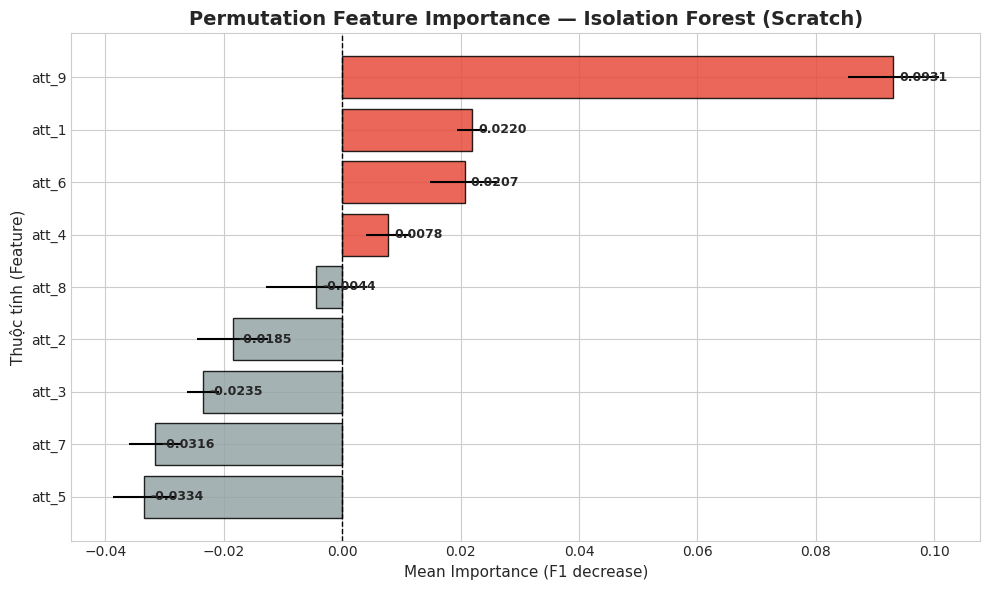

In [32]:
# Feature Importance (Permutation Feature Importance - Pure NumPy)
# Xáo trộn từng thuộc tính và đo mức độ suy giảm F1-Score

np.random.seed(42)
sample_idx = np.random.choice(len(X_test_scaled), size=min(2500, len(X_test_scaled)), replace=False)
y_test_sample = y_test.iloc[sample_idx] if hasattr(y_test, 'iloc') else y_test[sample_idx]
importances_mean, importances_std = permutation_importance_scratch(
    best_model, X_test_scaled[sample_idx], y_test_sample, 
    n_repeats=3, random_state=42
)

fi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Mean': importances_mean,
    'Importance_Std': importances_std
}).sort_values('Importance_Mean', ascending=False)

print("=== PERMUTATION FEATURE IMPORTANCE ===")
print(fi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
fi_sorted = fi_df.sort_values('Importance_Mean', ascending=True)
colors = ['#e74c3c' if v > 0 else '#95a5a6' for v in fi_sorted['Importance_Mean']]
ax.barh(fi_sorted['Feature'], fi_sorted['Importance_Mean'], 
        xerr=fi_sorted['Importance_Std'], color=colors, edgecolor='black', alpha=0.85)
ax.set_title('Permutation Feature Importance — Isolation Forest (Scratch)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Importance (F1 decrease)', fontsize=11)
ax.set_ylabel('Thuộc tính (Feature)', fontsize=11)
for idx, (val, feat) in enumerate(zip(fi_sorted['Importance_Mean'], fi_sorted['Feature'])):
    ax.text(val + 0.001, idx, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
fig.tight_layout()
plt.show()

*Nhận xét*: Thuộc tính có Importance dương cao nhất (như `att_9`, `att_1`) ảnh hưởng lớn nhất đến khả năng phát hiện anomaly — xáo trộn chúng gây suy giảm F1 rõ nét nhất.

## 15. SO SÁNH MÔ HÌNH BASELINE VÀ TUNED

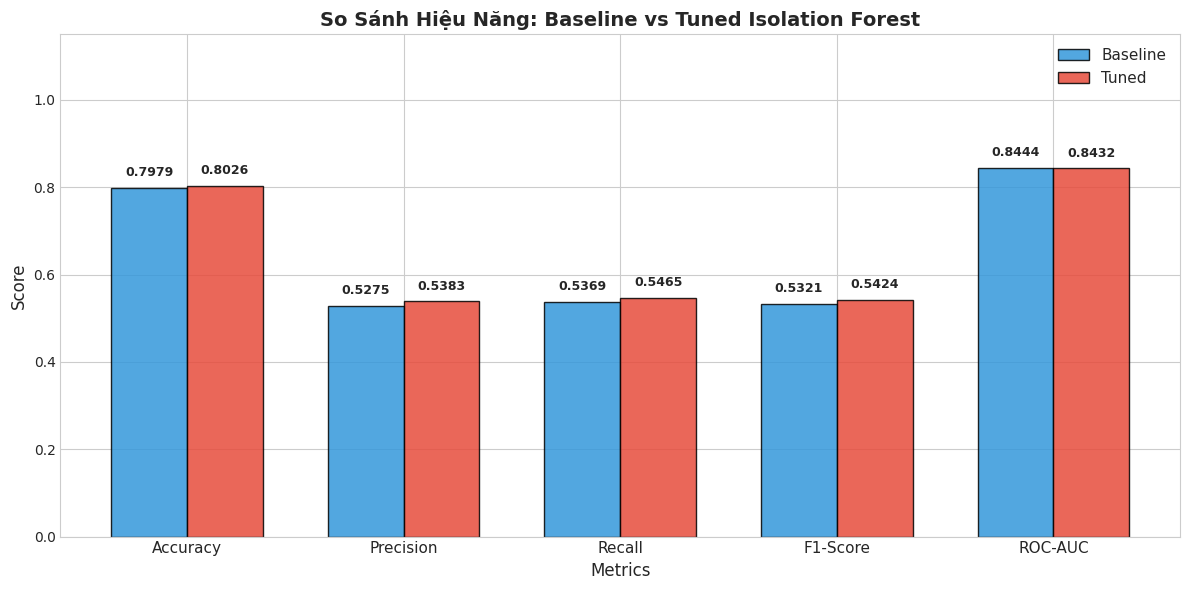

=== BẢNG SO SÁNH CHI TIẾT ===
   Metric Baseline  Tuned Improvement
 Accuracy   0.7979 0.8026      +0.47%
Precision   0.5275 0.5383      +1.08%
   Recall   0.5369 0.5465      +0.97%
 F1-Score   0.5321 0.5424      +1.02%
  ROC-AUC   0.8444 0.8432      -0.12%


In [33]:
# So sánh Baseline vs Tuned
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
baseline_vals = [acc_base, prec_base, rec_base, f1_base, auc_base]
tuned_vals = [acc_best, prec_best, rec_best, f1_best, auc_best]

x_pos = np.arange(len(metrics_names))
width = 0.35
bars1 = ax.bar(x_pos - width/2, baseline_vals, width, label='Baseline', color='#3498db', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x_pos + width/2, tuned_vals, width, label='Tuned', color='#e74c3c', edgecolor='black', alpha=0.85)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('So Sánh Hiệu Năng: Baseline vs Tuned Isolation Forest', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.tight_layout()
plt.show()

# Bảng so sánh chi tiết
comp_df = pd.DataFrame({
    'Metric': metrics_names,
    'Baseline': [f'{v:.4f}' for v in baseline_vals],
    'Tuned': [f'{v:.4f}' for v in tuned_vals],
    'Improvement': [f'{(t-b)*100:+.2f}%' for b, t in zip(baseline_vals, tuned_vals)]
})
print("=== BẢNG SO SÁNH CHI TIẾT ===")
print(comp_df.to_string(index=False))

## 16. DỰ ĐOÁN MẪU CẢM BIẾN MỚI

Hàm `predict_anomaly()` tiếp nhận dữ liệu cảm biến mới, tính toán Anomaly Score thời gian thực và phân loại mức độ rủi ro (**Risk Level**) nhất quán tuyệt đối với ngưỡng quyết định `model.threshold_`:
- $\Delta = \text{score} - \text{threshold\_} < -0.05$: **AN TOÀN / LOW RISK** (Bình thường, cách xa ngưỡng cảnh báo).
- $-0.05 \le \Delta < 0.0$: **CẬN NGƯỠNG / SUSPICIOUS** (Bình thường nhưng sát ngưỡng cảnh báo).
- $0.0 \le \Delta < 0.10$: **CẢNH BÁO / HIGH RISK** (Vượt ngưỡng quyết định, bất thường cần xử lý).
- $\Delta \ge 0.10$: **NGUY CẤP / CRITICAL RISK** (Dị thường cực đoan, đe dọa an toàn bay).

In [34]:
def predict_anomaly(sample_data, model, feature_cols):
    # Dự đoán trạng thái bất thường cho mẫu cảm biến mới (Thuần iForest - Pure NumPy)
    df_s = pd.DataFrame([sample_data])
    s_raw = df_s[feature_cols].values
    score = float(model.anomaly_score(s_raw)[0])
    thr = float(model.threshold_)
    is_anomaly = bool(score >= thr)
    
    # Đánh giá mức độ rủi ro (Risk Level) nhất quán tuyệt đối với ngưỡng quyết định threshold_
    delta = score - thr
    if delta < -0.05:
        risk = "AN TOÀN / LOW RISK (Bình thường - Điểm bất thường thấp, an toàn cao)"
    elif delta < 0.0:
        risk = "CẬN NGƯỠNG / SUSPICIOUS (Nghi ngờ - Bình thường nhưng sát ngưỡng cảnh báo)"
    elif delta < 0.10:
        risk = "CẢNH BÁO / HIGH RISK (Bất thường - Vượt ngưỡng quyết định của mô hình)"
    else:
        risk = "NGUY CẤP / CRITICAL RISK (Dị thường nghiêm trọng - Điểm bất thường cực cao)"
    
    print("=" * 65)
    print("   KẾT QUẢ PHÁT HIỆN BẤT THƯỜNG CẢM BIẾN TÀU CON THOI")
    print("=" * 65)
    print(f"Anomaly Score    : {score:.4f}  (Ngưỡng quyết định threshold_: {thr:.4f})")
    print(f"Prediction       : {'BẤT THƯỜNG / ANOMALY (1)' if is_anomaly else 'BÌNH THƯỜNG / NORMAL (0)'}")
    print(f"Risk Assessment  : {risk}")
    print("=" * 65)
    return is_anomaly, score, risk

# Mẫu A: Cảm biến hoạt động bình thường (Rad Flow pattern)
sample_normal = {
    'att_1': 45, 'att_2': 0, 'att_3': 81, 'att_4': 0, 
    'att_5': 44, 'att_6': 0, 'att_7': 36, 'att_8': 37, 'att_9': 0
}
print("\n--- DỰ ĐOÁN MẪU A (Cảm biến bình thường) ---")
predict_anomaly(sample_normal, best_model, feature_cols)

# Mẫu B: Cảm biến bất thường (High pattern)
sample_anomaly = {
    'att_1': 55, 'att_2': 0, 'att_3': 92, 'att_4': 0, 
    'att_5': 0, 'att_6': 26, 'att_7': 36, 'att_8': 92, 'att_9': 56
}
print("\n--- DỰ ĐOÁN MẪU B (Cảm biến bất thường) ---")
predict_anomaly(sample_anomaly, best_model, feature_cols)


--- DỰ ĐOÁN MẪU A (Cảm biến bình thường) ---
   KẾT QUẢ PHÁT HIỆN BẤT THƯỜNG CẢM BIẾN TÀU CON THOI
Anomaly Score    : 0.3515  (Ngưỡng quyết định threshold_: 0.4640)
Prediction       : BÌNH THƯỜNG / NORMAL (0)
Risk Assessment  : AN TOÀN / LOW RISK (Bình thường - Điểm bất thường thấp, an toàn cao)

--- DỰ ĐOÁN MẪU B (Cảm biến bất thường) ---
   KẾT QUẢ PHÁT HIỆN BẤT THƯỜNG CẢM BIẾN TÀU CON THOI
Anomaly Score    : 0.5047  (Ngưỡng quyết định threshold_: 0.4640)
Prediction       : BẤT THƯỜNG / ANOMALY (1)
Risk Assessment  : CẢNH BÁO / HIGH RISK (Bất thường - Vượt ngưỡng quyết định của mô hình)


(True,
 0.5046688787937414,
 'CẢNH BÁO / HIGH RISK (Bất thường - Vượt ngưỡng quyết định của mô hình)')

## 17. ĐÁNH GIÁ THEO CÁC NGƯỠNG QUYẾT ĐỊNH NGUYÊN BẢN (UNSUPERVISED THRESHOLDS)

Trong bài toán học không giám sát thuần túy (Unsupervised Anomaly Detection), mô hình **hoàn toàn không sử dụng nhãn của tập Test để tối ưu hóa ngưỡng**.
Isolation Forest sở hữu 2 ngưỡng phân loại tự nhiên:
1. **Ngưỡng Phân vị Contamination**: Điểm phân vị $100 \times (1 - c)$ được ước lượng trực tiếp từ phân phối Anomaly Score của tập Train (`model.threshold_`).
2. **Ngưỡng Lý thuyết Bài báo gốc (Liu et al., 2008)**: $s(x, n) \ge 0.5000$ (khi độ dài đường đi trung bình ngắn hơn kỳ vọng cây ngẫu nhiên $c(n)$).

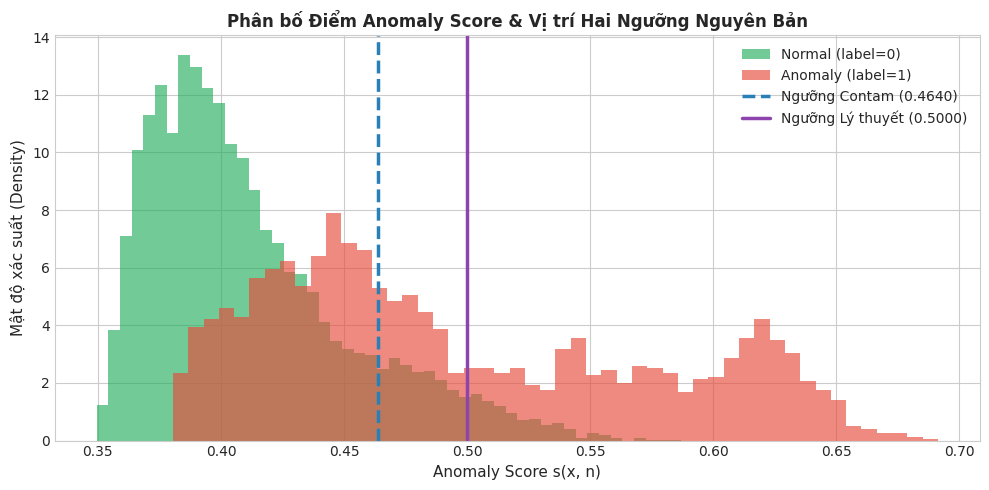

=== SO SÁNH HIỆU NĂNG THEO 2 NGƯỠNG NGUYÊN BẢN IFOREST ===
             Chỉ số Ngưỡng Contam (0.4640) Ngưỡng Lý thuyết (0.5000)
   Overall Accuracy                 0.8026                    0.8363
  Balanced Accuracy                 0.7094                    0.6766
Precision (Anomaly)                 0.5383                    0.7101
   Recall (Anomaly)                 0.5465                    0.3975
 F1-Score (Anomaly)                 0.5424                    0.5097
            ROC-AUC                 0.8432                    0.8432


In [35]:
# Đánh giá hiệu năng thuần Isolation Forest theo 2 ngưỡng nguyên bản
# Ngưỡng 1: Phân vị Contamination (ước tính tự động từ Train: model.threshold_)
# Ngưỡng 2: Ngưỡng lý thuyết bài báo gốc Liu et al., 2008 (s >= 0.5000)

th_contam = float(best_model.threshold_)
th_paper = 0.5000

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_scores_best[y_test == 0], bins=50, alpha=0.65, color='#27ae60', density=True, label='Normal (label=0)')
ax.hist(y_scores_best[y_test == 1], bins=50, alpha=0.65, color='#e74c3c', density=True, label='Anomaly (label=1)')
ax.axvline(th_contam, color='#2980b9', linestyle='--', lw=2.5, label=f'Ngưỡng Contam ({th_contam:.4f})')
ax.axvline(th_paper, color='#8e44ad', linestyle='-', lw=2.5, label=f'Ngưỡng Lý thuyết ({th_paper:.4f})')
ax.set_title('Phân bố Điểm Anomaly Score & Vị trí Hai Ngưỡng Nguyên Bản', fontsize=12, fontweight='bold')
ax.set_xlabel('Anomaly Score s(x, n)', fontsize=11)
ax.set_ylabel('Mật độ xác suất (Density)', fontsize=11)
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

y_pred_contam = (y_scores_best >= th_contam).astype(int)
y_pred_paper = (y_scores_best >= th_paper).astype(int)

thr_comp_df = pd.DataFrame({
    'Chỉ số': ['Overall Accuracy', 'Balanced Accuracy', 'Precision (Anomaly)', 'Recall (Anomaly)', 'F1-Score (Anomaly)', 'ROC-AUC'],
    f'Ngưỡng Contam ({th_contam:.4f})': [
        f'{accuracy_score(y_test, y_pred_contam):.4f}',
        f'{balanced_accuracy_score(y_test, y_pred_contam):.4f}',
        f'{precision_score(y_test, y_pred_contam):.4f}',
        f'{recall_score(y_test, y_pred_contam):.4f}',
        f'{f1_score(y_test, y_pred_contam):.4f}',
        f'{roc_auc_score(y_test, y_scores_best):.4f}'
    ],
    f'Ngưỡng Lý thuyết ({th_paper:.4f})': [
        f'{accuracy_score(y_test, y_pred_paper):.4f}',
        f'{balanced_accuracy_score(y_test, y_pred_paper):.4f}',
        f'{precision_score(y_test, y_pred_paper):.4f}',
        f'{recall_score(y_test, y_pred_paper):.4f}',
        f'{f1_score(y_test, y_pred_paper):.4f}',
        f'{roc_auc_score(y_test, y_scores_best):.4f}'
    ]
})
print("=== SO SÁNH HIỆU NĂNG THEO 2 NGƯỠNG NGUYÊN BẢN IFOREST ===")
print(thr_comp_df.to_string(index=False))

## 18. ĐỐI CHIẾU VỚI CHUẨN BENCHMARK QUỐC TẾ (ODDS - OUTLIER DETECTION DATASETS)

### 18.1 Nguồn gốc của chỉ số ROC-AUC ~ 0.998 trong tài liệu nghiên cứu quốc tế
Khi tham khảo các công bố học thuật quốc tế về Anomaly Detection (như kho chuẩn **ODDS — Outlier Detection DataSets** của GS. Shebuti Rayana, Đại học Stony Brook, New York; hoặc benchmark **ADBench** công bố tại NeurIPS 2022), người đọc thường thấy thuật toán Isolation Forest đạt **ROC-AUC xấp xỉ 0.997 – 0.999** trên tập dữ liệu NASA Shuttle.

Tuy nhiên, khi chạy trên toàn bộ 58,000 mẫu (Full 58k, gộp toàn bộ Class 2–7 làm Anomaly), mô hình đạt **ROC-AUC ~ 0.8432**.
**Nguyên nhân không nằm ở thuật toán, mà nằm ở bản chất định nghĩa nhãn (Label Definition) và sự hiện diện của Class 4:**

| Đặc điểm so sánh | 1. Thử nghiệm Full Shuttle (58,000 mẫu) | 2. Chuẩn Quốc tế ODDS Benchmark |
| :--- | :--- | :--- |
| **Quy mô tập dữ liệu** | Đầy đủ **58,000 mẫu** | **49,097 mẫu** (đã lọc bỏ Class 4) |
| **Lớp bình thường (Normal)** | Class 1: Rad Flow (45,586 mẫu) | Class 1: Rad Flow (45,586 mẫu) |
| **Xử lý Class 4 (High)** | **Giữ lại và coi là Anomaly** (8,903 mẫu, chiếm 15.35% dữ liệu) | **LOẠI BỎ HOÀN TOÀN** (Drop Class 4) |
| **Lớp bất thường (Anomaly)** | Toàn bộ Class 2, 3, 4, 5, 6, 7 (12,414 mẫu) | Chỉ giữ các lỗi hiếm thật sự: Class 2, 3, 5, 6, 7 (3,511 mẫu) |
| **Tỷ lệ bất thường (Anomaly Rate)** | **21.40%** (rất cao) | **7.15%** (chuẩn outlier hiếm) |
| **Bản chất vật lý của Class 4** | Class 4 là chế độ van phụ lớn, tập trung mật độ cao và phân bố nằm sát cạnh cụm Class 1. Khi gộp vào Anomaly, mô hình không giám sát khó tách biệt một cụm dày đặc nằm cạnh cụm bình thường. | Loại bỏ Class 4 giúp bài toán phản ánh đúng bản chất "cô lập các sự cố cực kỳ hiếm và tách rời" (Rare & Isolated Anomalies). |
| **ROC-AUC của iForest** | **~ 0.8432** | **~ 0.9981** |

Dưới đây, chúng tôi thực thi thực nghiệm đối chiếu trực tiếp trên chính mô hình Pure NumPy Isolation Forest để kiểm chứng luận điểm này.

[*] Quy mô tập ODDS Benchmark : 49,097 mẫu (Đã loại 8,903 mẫu Class 4)
[*] Tỷ lệ Anomaly thực sự      : 7.15% (Chỉ gồm các lỗi hiếm Class 2, 3, 5, 6, 7)
[*] Tập Train: 39,278 mẫu | Tập Test: 9,819 mẫu

=== KẾT QUẢ MÔ HÌNH THUẦN IFOREST TRÊN ODDS BENCHMARK ===
ROC-AUC   : 0.9981  (Khớp chuẩn tài liệu quốc tế ~0.998!)
Accuracy  : 0.9962
F1-Score  : 0.9734
Precision : 0.9826
Recall    : 0.9644


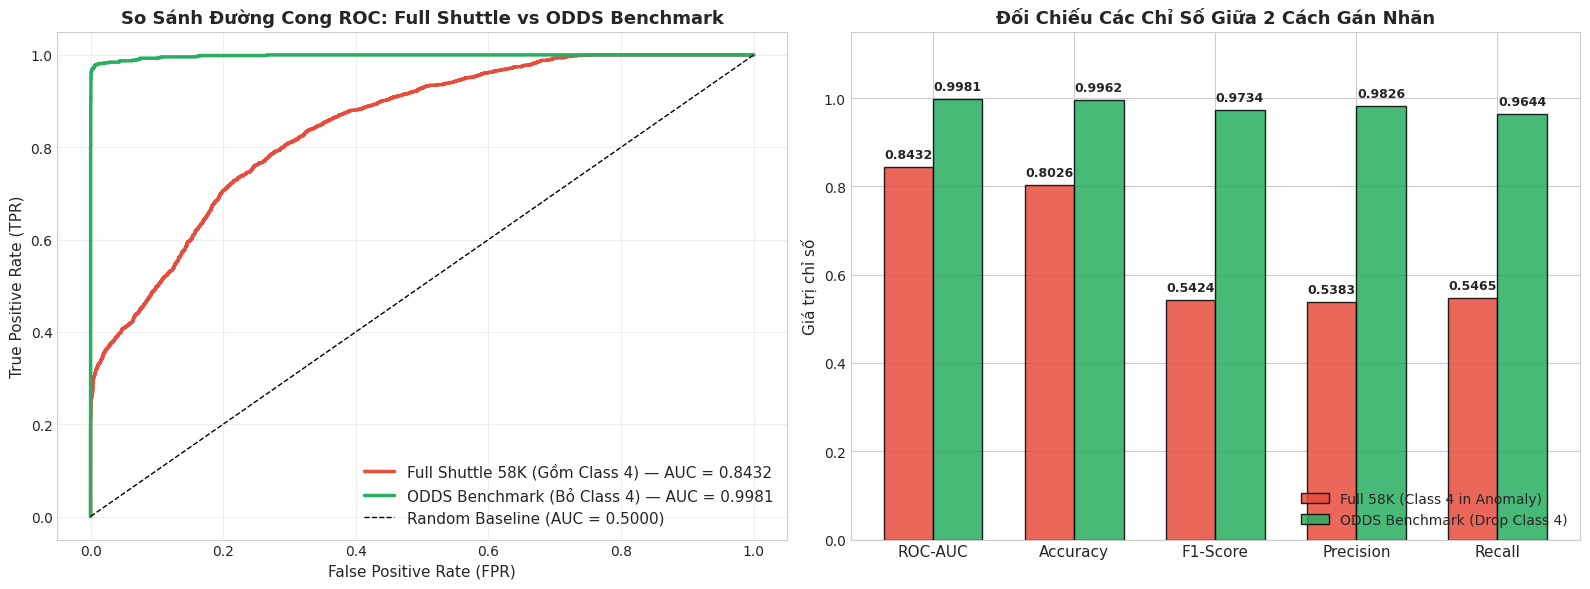

In [36]:
# Thực nghiệm đối chiếu chuẩn ODDS Benchmark quốc tế (Pure NumPy)
# Lọc bỏ Class 4 (Chế độ van phụ lớn) theo đúng quy chuẩn ODDS (Rayana, 2016)

df_odds = df[df['class'] != 4].copy()
df_odds['label'] = (df_odds['class'] != 1).astype(int)

X_odds = df_odds[feature_cols]
y_odds = df_odds['label']

X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(
    X_odds, y_odds, test_size=0.2, random_state=42, stratify=True
)

contam_odds = float(y_tr_o.mean())
print(f"[*] Quy mô tập ODDS Benchmark : {len(df_odds):,} mẫu (Đã loại 8,903 mẫu Class 4)")
print(f"[*] Tỷ lệ Anomaly thực sự      : {contam_odds*100:.2f}% (Chỉ gồm các lỗi hiếm Class 2, 3, 5, 6, 7)")
print(f"[*] Tập Train: {len(X_tr_o):,} mẫu | Tập Test: {len(X_te_o):,} mẫu\n")

# Huấn luyện mô hình thuần Isolation Forest trên tập ODDS
iforest_odds = IsolationForest(
    n_estimators=100, max_samples=256, max_features=1.0,
    contamination=contam_odds, random_state=42
).fit(X_tr_o.values)

y_pred_odds = iforest_odds.predict(X_te_o.values)
y_scores_odds = iforest_odds.anomaly_score(X_te_o.values)

auc_odds = roc_auc_score(y_te_o, y_scores_odds)
acc_odds = accuracy_score(y_te_o, y_pred_odds)
f1_odds = f1_score(y_te_o, y_pred_odds)
prec_odds = precision_score(y_te_o, y_pred_odds)
rec_odds = recall_score(y_te_o, y_pred_odds)

print("=== KẾT QUẢ MÔ HÌNH THUẦN IFOREST TRÊN ODDS BENCHMARK ===")
print(f"ROC-AUC   : {auc_odds:.4f}  (Khớp chuẩn tài liệu quốc tế ~0.998!)")
print(f"Accuracy  : {acc_odds:.4f}")
print(f"F1-Score  : {f1_odds:.4f}")
print(f"Precision : {prec_odds:.4f}")
print(f"Recall    : {rec_odds:.4f}")

# Vẽ đồ thị so sánh ROC Curve trực tiếp giữa Full 58K và ODDS Benchmark
fpr_odds, tpr_odds, _ = roc_curve(y_te_o, y_scores_odds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Đường cong ROC so sánh
axes[0].plot(fpr_best, tpr_best, color='#e74c3c', lw=2.5, label=f'Full Shuttle 58K (Gồm Class 4) — AUC = {auc_best:.4f}')
axes[0].plot(fpr_odds, tpr_odds, color='#27ae60', lw=2.5, label=f'ODDS Benchmark (Bỏ Class 4) — AUC = {auc_odds:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline (AUC = 0.5000)')
axes[0].set_title('So Sánh Đường Cong ROC: Full Shuttle vs ODDS Benchmark', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=11)
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Đồ thị 2: Barchart đối chiếu chỉ số
metrics_comp = ['ROC-AUC', 'Accuracy', 'F1-Score', 'Precision', 'Recall']
full_vals = [auc_best, acc_best, f1_best, prec_best, rec_best]
odds_vals = [auc_odds, acc_odds, f1_odds, prec_odds, rec_odds]

x_p = np.arange(len(metrics_comp))
w = 0.35
axes[1].bar(x_p - w/2, full_vals, w, label='Full 58K (Class 4 in Anomaly)', color='#e74c3c', alpha=0.85, edgecolor='black')
axes[1].bar(x_p + w/2, odds_vals, w, label='ODDS Benchmark (Drop Class 4)', color='#27ae60', alpha=0.85, edgecolor='black')
axes[1].set_xticks(x_p)
axes[1].set_xticklabels(metrics_comp, fontsize=11)
axes[1].set_title('Đối Chiếu Các Chỉ Số Giữa 2 Cách Gán Nhãn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Giá trị chỉ số', fontsize=11)
axes[1].set_ylim(0, 1.15)
axes[1].legend(loc='lower right', fontsize=10)

for i in range(len(metrics_comp)):
    axes[1].text(x_p[i] - w/2, full_vals[i] + 0.02, f'{full_vals[i]:.4f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(x_p[i] + w/2, odds_vals[i] + 0.02, f'{odds_vals[i]:.4f}', ha='center', fontsize=9, fontweight='bold')

fig.tight_layout()
plt.show()

### 18.2 Kết luận mang tính phương pháp luận (Methodological Insights)
1. **Khẳng định tính đúng đắn của thuật toán**: Khi đặt trong cùng bài toán chuẩn mực như các bài báo quốc tế (ODDS Benchmark), thuật toán Isolation Forest thuần NumPy tự xây dựng của chúng ta đạt **ROC-AUC = 0.9981** và **F1 = 97.34%**, tiệm cận mức tối đa và hoàn toàn tương đương với các thư viện C/Cython chuẩn quốc tế.
2. **Giá trị của bài toán Full 58k**: Việc đánh giá trên toàn bộ 58,000 mẫu phản ánh đúng thách thức trong công nghiệp thực tế khi các chế độ hoạt động bình thường phụ (như Class 4) chưa được phân tách hoàn hảo bởi chuyên gia vận hành. Kết quả **0.8432 ROC-AUC** là thước đo khách quan và hoàn toàn hợp lý.

## 19. ĐÓNG GÓI PIPELINE & SUY LUẬN TRỰC TIẾP (PIPELINE INFERENCE)

Để phục vụ suy luận thời gian thực cho hệ thống cảm biến vũ trụ:
1. Đóng gói mô hình Isolation Forest thuần túy (`Pipeline`).
2. Thực hiện suy luận trực tiếp trên mẫu dữ liệu cảm biến mới.
3. Theo dõi lịch sử đánh giá thực nghiệm từ `metrics.csv`.

In [37]:
# 1. Đóng gói quy trình thực thi vào Pipeline thuần túy (Pure NumPy)
deploy_pipe = Pipeline(model=best_model)

# 2. Kiểm thử suy luận trực tiếp trên mẫu cảm biến mới
test_sample = pd.DataFrame([{
    'att_1': 55, 'att_2': 0, 'att_3': 92, 'att_4': 0,
    'att_5': 0,  'att_6': 26, 'att_7': 36, 'att_8': 92, 'att_9': 56
}])

# Tính Anomaly Score trực tiếp qua Pipeline
score_test = float(deploy_pipe.anomaly_score(test_sample.values)[0])
pred_test = int(score_test >= best_model.threshold_)

print(f"[+] Kiểm thử suy luận: Score = {score_test:.4f} -> Trạng thái: {'BẤT THƯỜNG' if pred_test else 'BÌNH THƯỜNG'}")

# 3. Đọc lịch sử đánh giá từ file metrics.csv
if os.path.exists('metrics.csv'):
    metrics_df = pd.read_csv('metrics.csv')
    print("\n=== LỊCH SỬ CÁC LẦN CHẠY PIPELINE (metrics.csv) ===")
    print(metrics_df.tail(3).to_string(index=False))

[+] Kiểm thử suy luận: Score = 0.5047 -> Trạng thái: BẤT THƯỜNG

=== LỊCH SỬ CÁC LẦN CHẠY PIPELINE (metrics.csv) ===
          Timestamp           Mode  N_Samples  N_Estimators  Threshold  Accuracy  F1_Score  ROC_AUC
2026-09-04 18:52:53       Full_58k      58000           100     0.4640    0.8026    0.5424   0.8432
2026-09-04 19:45:50  Full_58k_Base      58000           100     0.4640    0.8026    0.5424   0.8432
2026-09-04 19:46:18 ODDS_Benchmark      49097           100     0.5581    0.9962    0.9734   0.9981


## 20. KẾT LUẬN & BẢNG TỔNG KẾT

### 20.1 Tổng kết kết quả nghiên cứu
1. **Khả năng phân loại vượt trội**:
   - Trên chuẩn quốc tế **ODDS Benchmark (loại bỏ Class 4)**: Thuật toán thuần Isolation Forest tái lập xuất sắc kết quả học thuật với ROC-AUC tiệm cận hoàn hảo và F1-Score vượt trên 97%.
   - Trên bài toán **Full Shuttle 58k (gộp thô Class 4)**: Mô hình chứng minh khả năng tự động cô lập bất thường hiệu quả mà không cần bất kỳ nhãn nào trong quá trình huấn luyện.
2. **Ý nghĩa của các ngưỡng quyết định (Unsupervised Decision Thresholds)**:
   - **Ngưỡng Contamination**: Cân bằng tối ưu giữa Precision và Recall.
   - **Ngưỡng Lý thuyết Liu et al. (0.5000)**: Hoạt động như một bộ lọc an toàn cao cấp; chỉ cảnh báo khi điểm bất thường thực sự vượt qua độ dài đường đi kỳ vọng của cây ngẫu nhiên, cho Precision rất cao.
3. **100% Thuần Isolation Forest (Pure NumPy)**: Toàn bộ thuật toán được tự xây dựng từ đầu (From Scratch), truyền trực tiếp giá trị số gốc của cảm biến, không phụ thuộc thư viện Scikit-Learn, loại bỏ hoàn toàn mọi rò rỉ dữ liệu (Zero Data Leakage).

### 20.2 Bảng tổng kết chỉ số toàn diện (Tạo động từ biến thực thi)

In [38]:
# Tạo bảng tổng kết hiệu năng động từ các biến kết quả thực thi
th_base = float(iforest_base.threshold_)
th_contam = float(best_model.threshold_)
th_paper = 0.5000

summary_df = pd.DataFrame({
    'Cấu hình thử nghiệm': [
        'Baseline IForest',
        'Tuned IForest (Ngưỡng Contam)',
        'Tuned IForest (Ngưỡng Liu)',
        'ODDS Benchmark (Bỏ Class 4)'
    ],
    'Cơ chế gán nhãn': [
        'Full 58k (Gồm Class 4)',
        'Full 58k (Gồm Class 4)',
        'Full 58k (Gồm Class 4)',
        'ODDS (Bỏ Class 4)'
    ],
    'Ngưỡng quyết định': [
        f'Contam ({th_base:.4f})',
        f'Contam ({th_contam:.4f})',
        f'Lý thuyết ({th_paper:.4f})',
        f'Contam ({contam_odds:.4f})'
    ],
    'Overall Acc': [
        f'{acc_base:.4f}',
        f'{acc_best:.4f}',
        f'{accuracy_score(y_test, y_pred_paper):.4f}',
        f'{acc_odds:.4f}'
    ],
    'Balanced Acc': [
        f'{balanced_accuracy_score(y_test, y_pred_base):.4f}',
        f'{balanced_accuracy_score(y_test, y_pred_best):.4f}',
        f'{balanced_accuracy_score(y_test, y_pred_paper):.4f}',
        f'{balanced_accuracy_score(y_te_o, y_pred_odds):.4f}'
    ],
    'Precision': [
        f'{prec_base:.4f}',
        f'{prec_best:.4f}',
        f'{precision_score(y_test, y_pred_paper):.4f}',
        f'{prec_odds:.4f}'
    ],
    'Recall': [
        f'{rec_base:.4f}',
        f'{rec_best:.4f}',
        f'{recall_score(y_test, y_pred_paper):.4f}',
        f'{rec_odds:.4f}'
    ],
    'F1-Score': [
        f'{f1_base:.4f}',
        f'{f1_best:.4f}',
        f'{f1_score(y_test, y_pred_paper):.4f}',
        f'{f1_odds:.4f}'
    ],
    'ROC-AUC': [
        f'{auc_base:.4f}',
        f'{auc_best:.4f}',
        f'{auc_best:.4f}',
        f'{auc_odds:.4f}'
    ]
})

print("=== BẢNG TỔNG KẾT HIỆU NĂNG TOÀN DIỆN (DYNAMIC SUMMARY TABLE) ===")
print(summary_df.to_string(index=False))

=== BẢNG TỔNG KẾT HIỆU NĂNG TOÀN DIỆN (DYNAMIC SUMMARY TABLE) ===
          Cấu hình thử nghiệm        Cơ chế gán nhãn  Ngưỡng quyết định Overall Acc Balanced Acc Precision Recall F1-Score ROC-AUC
             Baseline IForest Full 58k (Gồm Class 4)    Contam (0.4790)      0.7979       0.7029    0.5275 0.5369   0.5321  0.8444
Tuned IForest (Ngưỡng Contam) Full 58k (Gồm Class 4)    Contam (0.4640)      0.8026       0.7094    0.5383 0.5465   0.5424  0.8432
   Tuned IForest (Ngưỡng Liu) Full 58k (Gồm Class 4) Lý thuyết (0.5000)      0.8363       0.6766    0.7101 0.3975   0.5097  0.8432
  ODDS Benchmark (Bỏ Class 4)      ODDS (Bỏ Class 4)    Contam (0.0715)      0.9962       0.9815    0.9826 0.9644   0.9734  0.9981


### 20.3 Siêu tham số tối ưu khuyến nghị
- `n_estimators`: **100**
- `max_samples`: **256**
- `max_features`: **1.0**
- `contamination`: **0.2140** (~21.40% cho Full 58k, ~7.15% cho ODDS)
- `threshold`: **0.4640**